# Fitting with Gradients

This is what makes brainmass different. Because every model is a differentiable JAX program,
you can **backpropagate through the entire simulation** -- the ODE solve, the coupling, the
forward model -- and use the gradient of a loss to update model parameters. No finite
differences, no black-box search: the optimiser knows exactly which way to move every
parameter.

In this tutorial you will fit a model parameter to a target observation by gradient descent
with {class}`brainmass.Fitter` (`backend='grad'`). You will see:

1. a {class}`brainstate.nn.Param` marked `fit=True` to select what is trainable,
2. a `predict` that runs a {class}`~brainmass.Simulator` and reduces it to a **scalar
   summary**,
3. the gradient flowing from that scalar back through the solve to the parameter,
4. a loss curve that drops to near-zero in a few dozen evaluations.

:::{important}
For an **oscillatory** model, fit a *scalar summary* of the trajectory (amplitude, a spectral
feature, or functional connectivity) -- **not** the raw time series with a point-by-point
RMSE. Two limit cycles with the same shape but a different phase have a large pointwise RMSE,
so that loss is phase-degenerate and its gradient is uninformative. We fit the settled
**amplitude** here.
:::

In [1]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from brainstate.nn import Param, SoftplusT

brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## The model and the scalar summary

We use a supercritical {class}`~brainmass.HopfStep` oscillator. Above its bifurcation it
settles onto a limit cycle whose radius grows with the bifurcation parameter `a` (for the
normal form, amplitude scales as $\sqrt{a}$). We give it a small non-zero initial condition so
the trajectory spirals *out* to that limit cycle, then measure the **settled RMS amplitude**
after discarding the transient.

The summary -- a single number per simulation -- is what we will match to data.

In [2]:
def make_hopf(a, trainable=False):
    # When trainable, `a` is a bounded Param (fit=True selects it for optimisation).
    a_param = Param(a, t=SoftplusT(0.0), fit=True) if trainable else a
    return brainmass.HopfStep(
        in_size=1, a=a_param, w=0.3,
        init_x=braintools.init.Constant(0.5),   # kick off the spiral toward the limit cycle
        init_y=braintools.init.Constant(0.0),
    )

def settled_amplitude(node):
    '''Run the Simulator and reduce the trajectory to one scalar: the limit-cycle amplitude.'''
    res = brainmass.Simulator(node, dt=0.1 * u.ms).run(
        300.0 * u.ms, monitors=['x'], transient=150.0 * u.ms,
    )
    x = u.get_magnitude(res['x'])                # strip the mV-style unit before reducing
    return jnp.sqrt(jnp.mean(x ** 2)) * jnp.sqrt(2.0)   # RMS -> sinusoid amplitude

# The amplitude is a smooth, monotone function of `a` -- a well-conditioned target.
for a in [0.25, 1.0, 2.0]:
    print(f"a = {a:<4}  ->  amplitude = {float(settled_amplitude(make_hopf(a))):.3f}")

a = 0.25  ->  amplitude = 0.502
a = 1.0   ->  amplitude = 1.001
a = 2.0   ->  amplitude = 1.430


## The target

In a real study the target comes from data. Here we synthesise it by running the model at a
known "true" parameter `a* = 1.5` and recording its amplitude -- so we can check that the fit
recovers it.

In [3]:
target_amplitude = float(settled_amplitude(make_hopf(1.5)))
print(f"target amplitude (true a* = 1.5): {target_amplitude:.4f}")

target amplitude (true a* = 1.5): 1.2296


## Fit by backprop through the solve

Now the centrepiece. We start far from the truth (`a = 0.1`) and let {class}`~brainmass.Fitter`
minimise the squared error between the simulated amplitude and the target.

The `grad` backend does exactly the canonical loop: it collects the model's trainable
`ParamState` weights, evaluates the loss, and calls
`brainstate.transform.grad(...)` -- which differentiates **through the `Simulator.run`
`for_loop`** -- then steps the optax optimiser. We pass a `loss_fn(model) -> (loss, aux)` so we
own the scalar reduction; the `aux` (the amplitude) is carried along for inspection.

In [4]:
node = make_hopf(0.1, trainable=True)
print("trainable parameters:", list(node.states(brainstate.ParamState).keys()))

def loss_fn(model):
    amp = settled_amplitude(model)
    loss = (amp - target_amplitude) ** 2
    return loss, amp                      # aux = current amplitude

fitter = brainmass.Fitter(
    node,
    braintools.optim.Adam(lr=0.1),        # grad backend takes a braintools.optim optimiser
    loss_fn=loss_fn,
    backend='grad',
)
result = fitter.fit(n_steps=60, verbose=False)

print(f"fitted a   : {float(result.best_params['a']):.4f}   (true a* = 1.5)")
print(f"best loss  : {result.best_loss:.2e}")
print(f"loss drop  : {result.history[0]:.4f}  ->  {result.best_loss:.2e}")
print(f"evaluations: {len(result.history)}")

trainable parameters: [('a', 'val')]


fitted a   : 1.5471   (true a* = 1.5)
best loss  : 3.37e-05
loss drop  : 0.8262  ->  3.37e-05
evaluations: 60


The fit recovers `a* ~ 1.5` and the loss collapses by several orders of magnitude. Plotting the
full loss history shows the characteristic smooth descent of a gradient method -- each step
moves *downhill*, because the gradient told it which way that is.

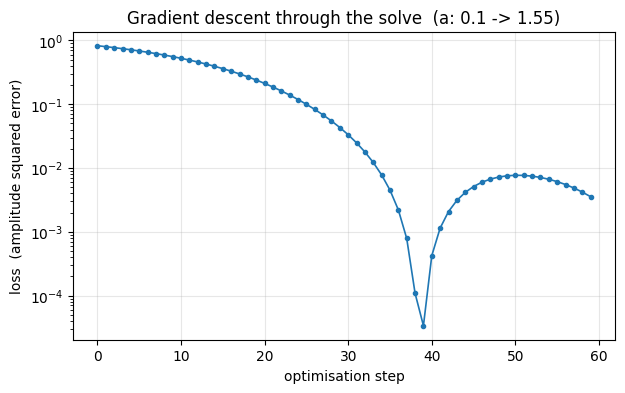

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(result.history, marker='.', lw=1.2)
ax.set_yscale('log')
ax.set_xlabel('optimisation step')
ax.set_ylabel('loss  (amplitude squared error)')
ax.set_title(f"Gradient descent through the solve  (a: 0.1 -> {float(result.best_params['a']):.2f})")
ax.grid(alpha=0.3)
plt.show()

## Confirming the gradient is real

To make the differentiability concrete, take the gradient of the loss with respect to `a`
directly with {func}`brainstate.transform.grad` and compare it to a finite-difference estimate.
We use a *plain* (untransformed) `Param` here so autodiff and finite differences live in the
**same** space: with a transform like `SoftplusT`, autodiff returns the gradient in the
optimiser's unconstrained space, which differs from a physical-space finite difference by the
transform's Jacobian (correct, but not directly comparable). With no transform they agree to
several digits -- the gradient that drove the fit above genuinely flows back through the entire
{class}`~brainmass.Simulator` rollout.

In [6]:
from brainstate.nn import Param as _Param

def loss_at(a_value):
    # Plain trainable param (no transform): unconstrained space == physical space.
    n = brainmass.HopfStep(in_size=1, a=_Param(a_value, fit=True), w=0.3,
                           init_x=braintools.init.Constant(0.5),
                           init_y=braintools.init.Constant(0.0))
    weights = n.states(brainstate.ParamState)
    (key,) = weights.keys()                       # the single trainable weight ('a', 'val')
    grad_fn = brainstate.transform.grad(
        lambda: (settled_amplitude(n) - target_amplitude) ** 2,
        weights, return_value=True,
    )
    grads, loss = grad_fn()
    return float(loss), float(grads[key])

a0 = 0.8
loss0, autodiff_grad = loss_at(a0)
eps = 1e-3
fd_grad = (loss_at(a0 + eps)[0] - loss_at(a0 - eps)[0]) / (2 * eps)
print(f"autodiff d(loss)/da  = {autodiff_grad:+.5f}")
print(f"finite-difference    = {fd_grad:+.5f}")

autodiff d(loss)/da  = -0.36418
finite-difference    = -0.36414


## Selecting trainables and composing objectives

Two pieces generalise this to richer problems.

**`Param(fit=True)` selects what is trainable.** Only parameters wrapped in a
{class}`~brainstate.nn.Param` with `fit=True` become `ParamState` weights; everything else is
held fixed. A transform such as {class}`~brainstate.nn.SoftplusT` keeps the parameter in a
valid range (here `a > 0`) while the optimiser works in unconstrained space.

**{mod}`brainmass.objectives` composes losses.** When you fit to a *signal* rather than a
hand-written scalar, build the loss from the objective library -- e.g. match functional
connectivity with {func}`~brainmass.objectives.fc_corr`, or combine several terms with
{func}`~brainmass.objectives.combine`. The example below fits a coupling gain so a 3-region
Hopf network reproduces a target FC, using `fc_corr(as_loss=True)` (which returns `1 - corr`,
so minimising it *maximises* the correlation).

In [7]:
# A 3-region driven network whose FC depends on a trainable coupling gain k.
W = jnp.asarray([[0.0, 0.8, 0.2],
                 [0.8, 0.0, 0.5],
                 [0.2, 0.5, 0.0]])

def make_net(k_value, trainable=False):
    k = Param(k_value, t=SoftplusT(0.0), fit=True) if trainable else k_value
    n = brainmass.HopfStep(in_size=3, a=0.5, w=0.3,
                           noise_x=brainmass.OUProcess(3, sigma=0.3, tau=10.0 * u.ms))
    return brainmass.Network(n, conn=W, coupling='diffusive', coupled_var='x', k=k)

def predict_fc(net):
    res = brainmass.Simulator(net, dt=0.1 * u.ms).run(
        400.0 * u.ms, monitors=lambda m: m.node.x.value, transient=100.0 * u.ms,
    )
    return res['output']                          # (T, 3) time series -> FC computed by objective

# Target FC from a known coupling k* = 1.0.
brainstate.random.seed(1)
target_fc = predict_fc(make_net(1.0))

fc_loss = brainmass.objectives.fc_corr(as_loss=True)   # 1 - corr(FC_pred, FC_target)

brainstate.random.seed(1)
net = make_net(0.1, trainable=True)
fc_fitter = brainmass.Fitter(
    net, braintools.optim.Adam(lr=0.2),
    predict=predict_fc, objective=fc_loss, backend='grad',
)
fc_result = fc_fitter.fit(target=target_fc, n_steps=60)
print(f"fitted k  : {float(fc_result.best_params['coupling.k']):.3f}   (true k* = 1.0)")
print(f"FC loss   : {fc_result.history[0]:.3f}  ->  {fc_result.best_loss:.3f}")

fitted k  : 1.183   (true k* = 1.0)
FC loss   : 0.158  ->  0.000


## Why gradients

The fit above converged in a few dozen forward simulations, and every one of those steps was
informed by the gradient -- the optimiser never had to guess a direction. That efficiency is
the whole point of a *differentiable* simulator: for problems with more than a handful of
parameters (whole-brain coupling matrices, lead-field heads, task-trained networks),
gradient-based fitting is the only thing that scales.

But gradients are not always available -- a non-differentiable objective, a discrete choice, a
black-box metric. The next tutorial fits the *same* amplitude target with **gradient-free**
search and contrasts the cost.

## Summary

- brainmass models are differentiable, so {class}`~brainmass.Fitter` with `backend='grad'`
  **backpropagates through the `Simulator` solve**.
- Mark trainables with `Param(..., fit=True)`; reduce the trajectory to a **scalar summary**
  (amplitude / FC / spectrum), never a phase-sensitive pointwise RMSE.
- The loss curve drops smoothly; autodiff and finite-difference gradients agree.
- Compose richer losses from {mod}`brainmass.objectives`.

## Next steps

- {doc}`/tutorials/07_gradient_free_fitting` -- the same fit without gradients, and when to
  prefer it.
- {doc}`/tutorials/08_training_on_tasks` -- train a network on a cognitive task over epochs.
- {doc}`/reference/orchestration` -- {class}`~brainmass.Fitter` / {class}`~brainmass.FitResult`
  API.